# TaaSim — Porto Taxi Trajectories: Exploratory Data Analysis

**Dataset**: Porto Taxi Trajectories (ECML/PKDD 2015 Challenge)  
**Source**: Kaggle / UCI ML Repository  
**Volume**: ~1.7M completed taxi trips · 442 taxis · July 2013–June 2014  

## Objectives
1. Schema inspection and data quality assessment
2. MISSING_DATA analysis and exclusion strategy
3. POLYLINE parsing and trip duration distribution
4. CALL_TYPE breakdown (A=dispatch, B=stand, C=street hail)
5. Temporal demand curve (hour-of-day, day-of-week)
6. Peak hours and weekend vs weekday patterns

In [1]:
# Cell 1: Imports and Setup
import json
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import numpy as np
import pandas as pd
from datetime import datetime

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["figure.dpi"] = 100

print("Libraries loaded.")

Libraries loaded.


## 1. Load Porto Dataset and Schema Inspection

In [2]:
# Cell 2: Load CSV from local data folder
df = pd.read_csv("../data/train.csv")

print(f"Total rows: {len(df):,}")
print(f"Total columns: {len(df.columns)}")
print(f"\nColumn names: {list(df.columns)}")
print(f"\nDataset shape: {df.shape}")

Total rows: 1,710,670
Total columns: 9

Column names: ['TRIP_ID', 'CALL_TYPE', 'ORIGIN_CALL', 'ORIGIN_STAND', 'TAXI_ID', 'TIMESTAMP', 'DAY_TYPE', 'MISSING_DATA', 'POLYLINE']

Dataset shape: (1710670, 9)


In [3]:
# Cell 3: Schema details
print("=== SCHEMA (dtypes) ===")
print(df.dtypes)
print(f"\n=== MEMORY USAGE ===")
print(f"{df.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print(f"\n=== FIRST 3 ROWS ===")
df.head(3)

=== SCHEMA (dtypes) ===
TRIP_ID           int64
CALL_TYPE           str
ORIGIN_CALL     float64
ORIGIN_STAND    float64
TAXI_ID           int64
TIMESTAMP         int64
DAY_TYPE            str
MISSING_DATA       bool
POLYLINE            str
dtype: object

=== MEMORY USAGE ===
2143.2 MB

=== FIRST 3 ROWS ===


,TRIP_ID,CALL_TYPE,ORIGIN_CALL,ORIGIN_STAND,TAXI_ID,TIMESTAMP,DAY_TYPE,MISSING_DATA,POLYLINE
0,1372636858620000589,C,NaN,NaN,20000589,1372636858,A,False,"[[-8.618643,41.141412],[-8.618499,41.141376],[..."
1,1372637303620000596,B,NaN,7.0,20000596,1372637303,A,False,"[[-8.639847,41.159826],[-8.640351,41.159871],[..."
2,1372636951620000320,C,NaN,NaN,20000320,1372636951,A,False,"[[-8.612964,41.140359],[-8.613378,41.14035],[-..."


In [4]:
# Cell 4: Null and Missing analysis
print("=== NULL COUNTS PER COLUMN ===")
null_counts = df.isnull().sum()
print(null_counts)

print(f"\n=== MISSING_DATA FIELD ===")
missing_counts = df["MISSING_DATA"].value_counts()
print(missing_counts)
missing_pct = (missing_counts.get(True, 0) / len(df)) * 100
print(f"\nMISSING_DATA=True: {missing_counts.get(True, 0):,} rows ({missing_pct:.2f}%)")
print(f"MISSING_DATA=False: {missing_counts.get(False, 0):,} rows ({100-missing_pct:.2f}%)")

print(f"\n=== EXCLUSION STRATEGY ===")
print("Rows with MISSING_DATA=True have incomplete GPS polylines.")
print("These will be EXCLUDED from trip duration and zone analyses.")
print("They CAN be kept for call_type and temporal demand analyses (timestamp is valid).")

=== NULL COUNTS PER COLUMN ===
TRIP_ID               0
CALL_TYPE             0
ORIGIN_CALL     1345900
ORIGIN_STAND     904091
TAXI_ID               0
TIMESTAMP             0
DAY_TYPE              0
MISSING_DATA          0
POLYLINE              0
dtype: int64

=== MISSING_DATA FIELD ===
MISSING_DATA
False    1710660
True          10
Name: count, dtype: int64

MISSING_DATA=True: 10 rows (0.00%)
MISSING_DATA=False: 1,710,660 rows (100.00%)

=== EXCLUSION STRATEGY ===
Rows with MISSING_DATA=True have incomplete GPS polylines.
These will be EXCLUDED from trip duration and zone analyses.
They CAN be kept for call_type and temporal demand analyses (timestamp is valid).


## 2. POLYLINE Parsing and Trip Duration Distribution

Each GPS point in the POLYLINE is recorded every 15 seconds.  
**Trip duration = number_of_GPS_points × 15 seconds**

In [5]:
# Cell 5: Parse POLYLINE length and compute trip duration
df_valid = df[df["MISSING_DATA"] == False].copy()

def count_gps_points(polyline_str):
    try:
        coords = json.loads(polyline_str)
        return len(coords)
    except:
        return 0

df_valid["gps_points"] = df_valid["POLYLINE"].apply(count_gps_points)
df_valid["duration_sec"] = df_valid["gps_points"] * 15
df_valid["duration_min"] = df_valid["duration_sec"] / 60

# Remove trips with 0 or 1 GPS points (invalid)
df_valid = df_valid[df_valid["gps_points"] > 1]

print(f"Valid trips (non-missing, >1 GPS point): {len(df_valid):,}")
print(f"\n=== TRIP DURATION STATS (minutes) ===")
print(df_valid["duration_min"].describe().round(2))
print(f"\nMedian: {df_valid['duration_min'].median():.1f} min")

Valid trips (non-missing, >1 GPS point): 1,674,152

=== TRIP DURATION STATS (minutes) ===
count    1674152.00
mean          12.45
std           11.40
min            0.50
25%            7.25
50%           10.50
75%           14.75
max          970.25
Name: duration_min, dtype: float64

Median: 10.5 min


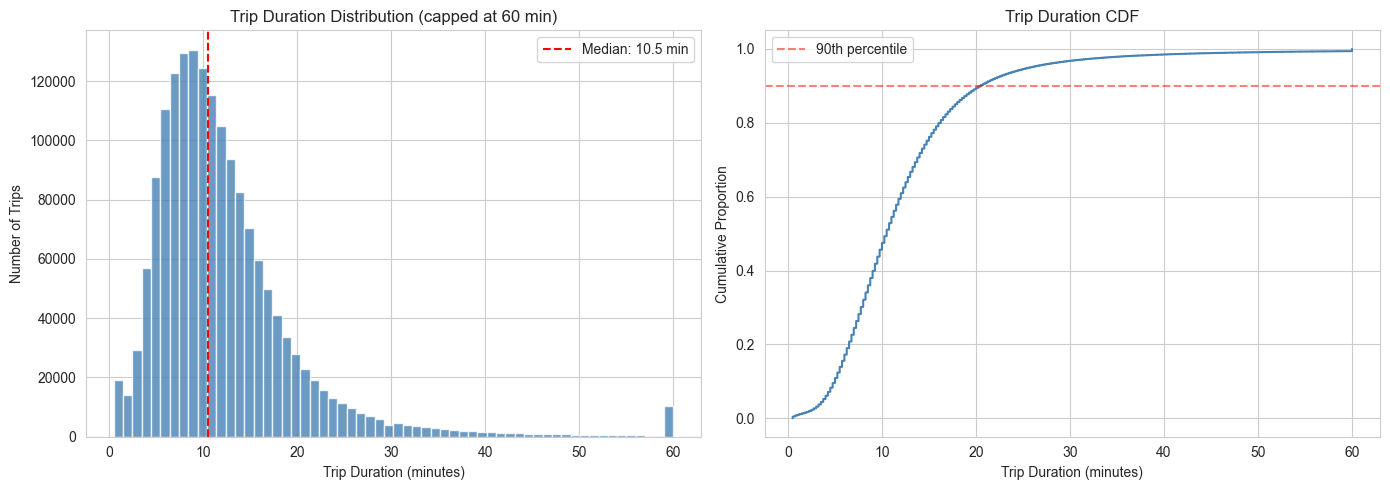

  P25: 7.2 min
  P50: 10.5 min
  P75: 14.8 min
  P90: 20.5 min
  P95: 25.8 min
  P99: 47.8 min


In [6]:
# Cell 6: Trip duration histogram
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Distribution (capped at 60 min)
dur_capped = df_valid["duration_min"].clip(upper=60)
axes[0].hist(dur_capped, bins=60, color="steelblue", edgecolor="white", alpha=0.8)
axes[0].set_xlabel("Trip Duration (minutes)")
axes[0].set_ylabel("Number of Trips")
axes[0].set_title("Trip Duration Distribution (capped at 60 min)")
axes[0].axvline(df_valid["duration_min"].median(), color="red", linestyle="--",
                label=f'Median: {df_valid["duration_min"].median():.1f} min')
axes[0].legend()

# Right: CDF
sorted_dur = np.sort(dur_capped)
cdf = np.arange(1, len(sorted_dur)+1) / len(sorted_dur)
axes[1].plot(sorted_dur, cdf, color="steelblue")
axes[1].set_xlabel("Trip Duration (minutes)")
axes[1].set_ylabel("Cumulative Proportion")
axes[1].set_title("Trip Duration CDF")
axes[1].axhline(0.9, color="red", linestyle="--", alpha=0.5, label="90th percentile")
axes[1].legend()

plt.tight_layout()
plt.show()

for p in [25, 50, 75, 90, 95, 99]:
    val = np.percentile(df_valid["duration_min"], p)
    print(f"  P{p}: {val:.1f} min")

## 3. CALL_TYPE Breakdown

- **A** = Dispatched from central (phone/app call)
- **B** = Picked up at taxi stand
- **C** = Street hail (flagged down)

This mirrors Casablanca taxi patterns exactly.

=== CALL_TYPE BREAKDOWN ===
  Type A (Dispatch (Central)):    364,770 trips  (21.32%)
  Type B (Taxi Stand):    817,881 trips  (47.81%)
  Type C (Street Hail):    528,019 trips  (30.87%)


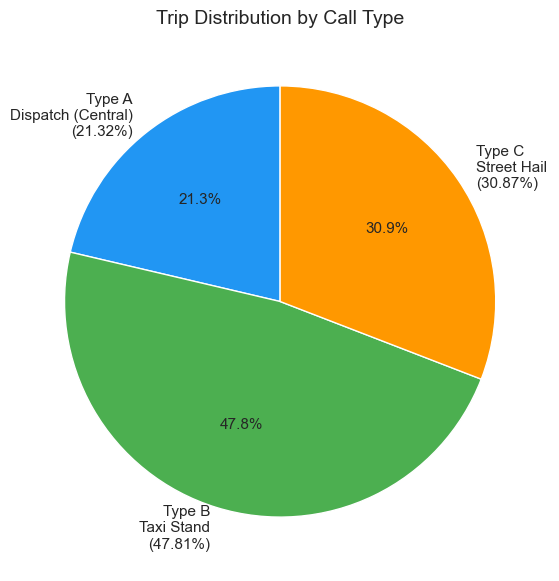

In [7]:
# Cell 7: CALL_TYPE analysis
call_type_map = {"A": "Dispatch (Central)", "B": "Taxi Stand", "C": "Street Hail"}

call_counts = df["CALL_TYPE"].value_counts()
call_pct = (call_counts / len(df) * 100).round(2)

print("=== CALL_TYPE BREAKDOWN ===")
for ct in ["A", "B", "C"]:
    count = call_counts.get(ct, 0)
    pct = call_pct.get(ct, 0)
    print(f"  Type {ct} ({call_type_map[ct]}): {count:>10,} trips  ({pct}%)")

fig, ax = plt.subplots(figsize=(7, 7))
labels = [f"Type {ct}\n{call_type_map[ct]}\n({call_pct.get(ct, 0)}%)" for ct in ["A", "B", "C"]]
colors = ["#2196F3", "#4CAF50", "#FF9800"]
sizes = [call_counts.get(ct, 0) for ct in ["A", "B", "C"]]
ax.pie(sizes, labels=labels, colors=colors, autopct="%1.1f%%", startangle=90, textprops={"fontsize": 11})
ax.set_title("Trip Distribution by Call Type", fontsize=14)
plt.show()

## 4. Temporal Demand Curve

Analyze trips by **hour-of-day** and **day-of-week** to identify peak demand patterns.

In [8]:
# Cell 8: Extract temporal features
df["datetime"] = pd.to_datetime(df["TIMESTAMP"], unit="s")
df["hour"] = df["datetime"].dt.hour
df["day_of_week"] = df["datetime"].dt.dayofweek  # 0=Mon, 6=Sun
df["day_name"] = df["datetime"].dt.day_name()
df["is_weekend"] = df["day_of_week"].isin([5, 6])
df["month"] = df["datetime"].dt.month
df["date"] = df["datetime"].dt.date

print(f"Date range: {df['datetime'].min()} to {df['datetime'].max()}")
print(f"Duration: {(df['datetime'].max() - df['datetime'].min()).days} days")
print(f"\nDay of week distribution:")
print(df["day_name"].value_counts().sort_index())

Date range: 2013-07-01 00:00:53 to 2014-06-30 23:59:56
Duration: 364 days

Day of week distribution:
day_name
Friday       277313
Monday       229948
Saturday     258636
Sunday       230397
Thursday     247025
Tuesday      234734
Wednesday    232617
Name: count, dtype: int64


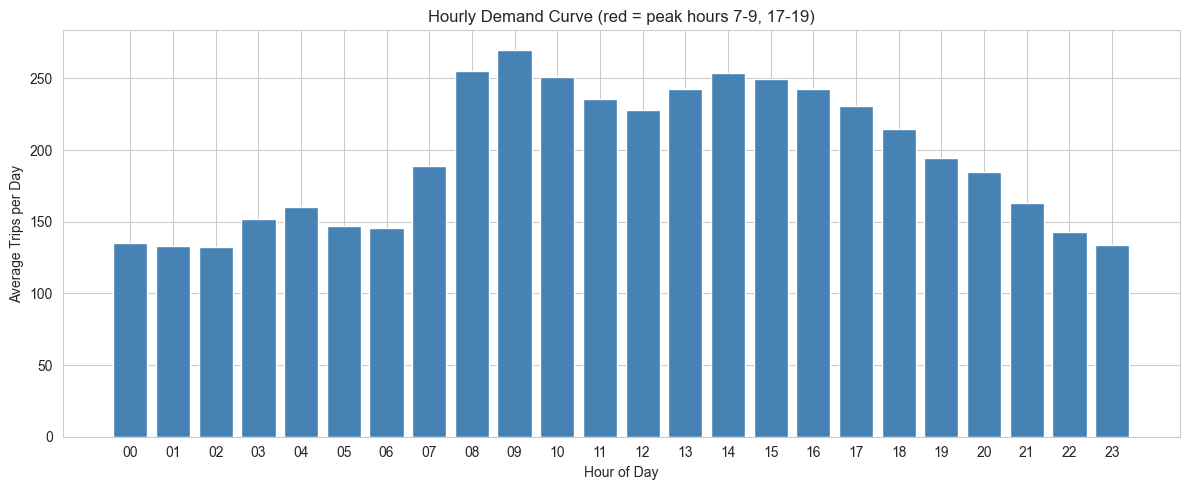

=== TOP 5 BUSIEST HOURS ===
  09:00 -- 270 avg trips/day
  08:00 -- 255 avg trips/day
  14:00 -- 254 avg trips/day
  10:00 -- 251 avg trips/day
  15:00 -- 249 avg trips/day


In [9]:
# Cell 9: Hourly demand curve
hourly = df.groupby("hour").size().reset_index(name="total_trips")
n_days = df["date"].nunique()
hourly["avg_trips_per_day"] = hourly["total_trips"] / n_days

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(hourly["hour"], hourly["avg_trips_per_day"], color="steelblue", edgecolor="white")

for bar in bars:
    if bar.get_x() + 0.5 in [7, 8, 17, 18]:
        bar.set_color("#e74c3c")

ax.set_xlabel("Hour of Day")
ax.set_ylabel("Average Trips per Day")
ax.set_title("Hourly Demand Curve (red = peak hours 7-9, 17-19)")
ax.set_xticks(range(24))
ax.set_xticklabels([f"{h:02d}" for h in range(24)])
plt.tight_layout()
plt.show()

top5 = hourly.nlargest(5, "avg_trips_per_day")
print("=== TOP 5 BUSIEST HOURS ===")
for _, row in top5.iterrows():
    print(f"  {int(row['hour']):02d}:00 -- {row['avg_trips_per_day']:.0f} avg trips/day")

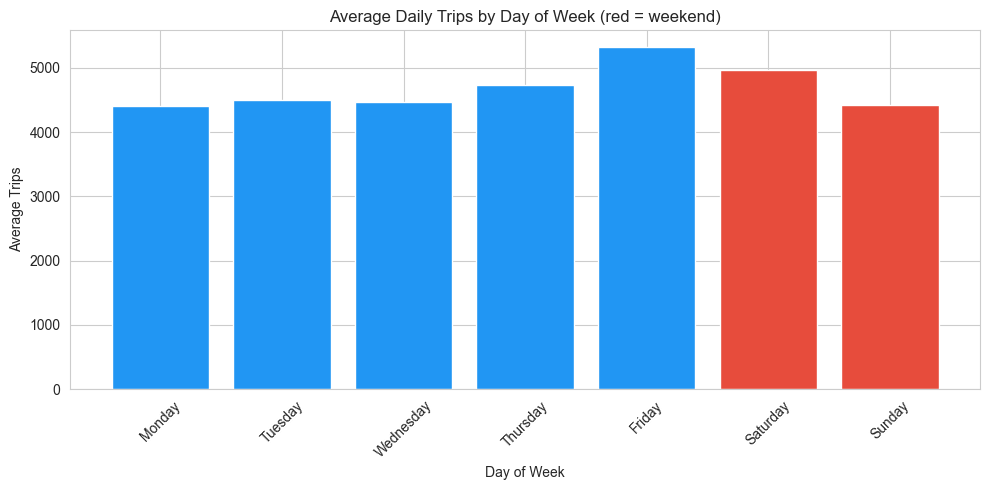

Weekday avg: 4,686 trips/day
Weekend avg: 4,689 trips/day
Ratio: weekend is 100.1% of weekday demand


In [10]:
# Cell 10: Day-of-week pattern
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
daily = df.groupby("day_name").size().reset_index(name="total_trips")
daily["day_name"] = pd.Categorical(daily["day_name"], categories=day_order, ordered=True)
daily = daily.sort_values("day_name")
n_weeks = n_days / 7
daily["avg_trips_per_day"] = daily["total_trips"] / n_weeks

fig, ax = plt.subplots(figsize=(10, 5))
colors_bar = ["#2196F3"] * 5 + ["#e74c3c"] * 2
ax.bar(daily["day_name"], daily["avg_trips_per_day"], color=colors_bar, edgecolor="white")
ax.set_xlabel("Day of Week")
ax.set_ylabel("Average Trips")
ax.set_title("Average Daily Trips by Day of Week (red = weekend)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

weekday_avg = daily[daily["day_name"].isin(day_order[:5])]["avg_trips_per_day"].mean()
weekend_avg = daily[daily["day_name"].isin(day_order[5:])]["avg_trips_per_day"].mean()
print(f"Weekday avg: {weekday_avg:,.0f} trips/day")
print(f"Weekend avg: {weekend_avg:,.0f} trips/day")
print(f"Ratio: weekend is {weekend_avg/weekday_avg:.1%} of weekday demand")

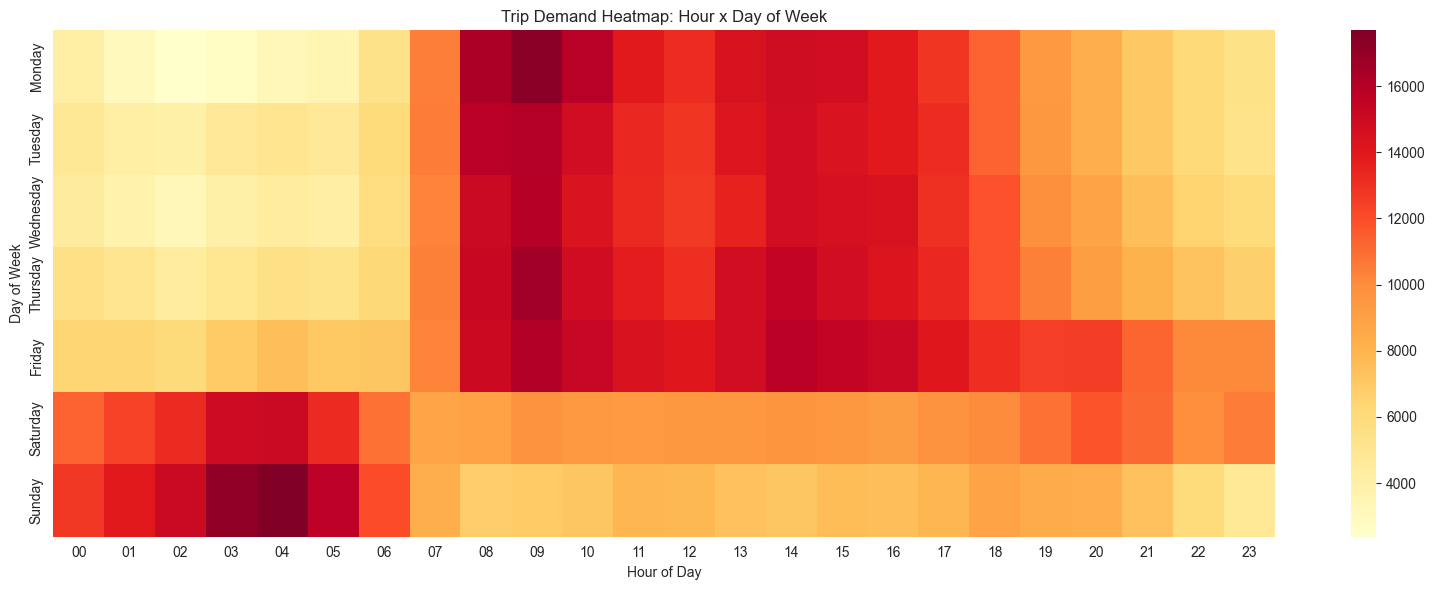

In [11]:
# Cell 11: Heatmap - Hour x Day-of-Week
pivot = df.groupby(["day_of_week", "hour"]).size().reset_index(name="trips")
pivot_table = pivot.pivot(index="day_of_week", columns="hour", values="trips").fillna(0)
pivot_table.index = day_order

fig, ax = plt.subplots(figsize=(16, 6))
sns.heatmap(pivot_table, cmap="YlOrRd", annot=False, fmt=".0f", ax=ax,
            xticklabels=[f"{h:02d}" for h in range(24)])
ax.set_xlabel("Hour of Day")
ax.set_ylabel("Day of Week")
ax.set_title("Trip Demand Heatmap: Hour x Day of Week")
plt.tight_layout()
plt.show()

## 5. Additional Insights

In [12]:
# Cell 12: Taxi and Origin analysis
print("=== ORIGIN_STAND Distribution (top 10) ===")
stand_counts = df[df["CALL_TYPE"] == "B"]["ORIGIN_STAND"].value_counts().head(10)
print(stand_counts)

print(f"\n=== TAXI_ID Stats ===")
taxi_trips = df["TAXI_ID"].value_counts()
print(f"  Unique taxis: {df['TAXI_ID'].nunique()}")
print(f"  Most active taxi: {taxi_trips.index[0]} ({taxi_trips.iloc[0]:,} trips)")
print(f"  Least active taxi: {taxi_trips.index[-1]} ({taxi_trips.iloc[-1]:,} trips)")
print(f"  Avg trips per taxi: {taxi_trips.mean():.0f}")
print(f"  Median trips per taxi: {taxi_trips.median():.0f}")

print(f"\n=== DAY_TYPE Distribution ===")
print(df["DAY_TYPE"].value_counts())

=== ORIGIN_STAND Distribution (top 10) ===
ORIGIN_STAND
15.0    80241
57.0    50882
9.0     34818
33.0    34128
23.0    33344
18.0    32937
53.0    31712
13.0    25685
12.0    25434
36.0    24754
Name: count, dtype: int64

=== TAXI_ID Stats ===
  Unique taxis: 448
  Most active taxi: 20000080 (10,746 trips)
  Least active taxi: 20000931 (1 trips)
  Avg trips per taxi: 3818
  Median trips per taxi: 3732

=== DAY_TYPE Distribution ===
DAY_TYPE
A    1710670
Name: count, dtype: int64


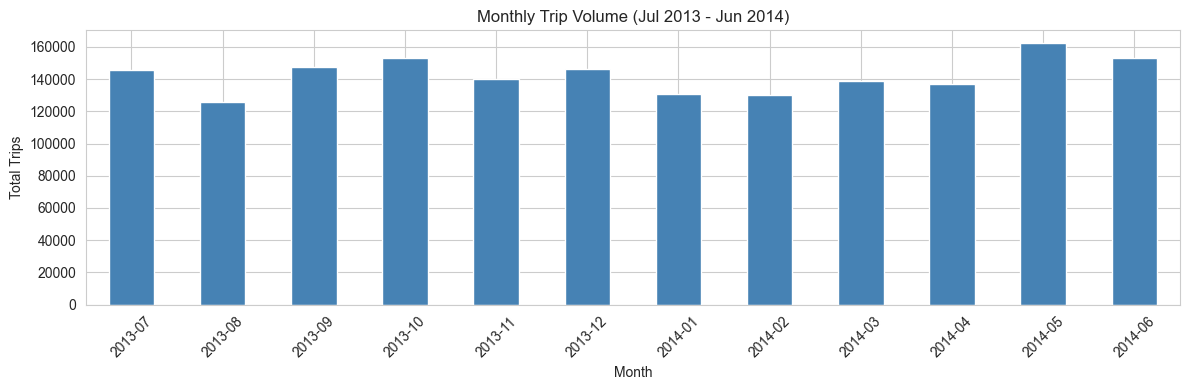

In [13]:
# Cell 13: Monthly trend
monthly = df.groupby(df["datetime"].dt.to_period("M")).size()
fig, ax = plt.subplots(figsize=(12, 4))
monthly.plot(kind="bar", color="steelblue", edgecolor="white", ax=ax)
ax.set_xlabel("Month")
ax.set_ylabel("Total Trips")
ax.set_title("Monthly Trip Volume (Jul 2013 - Jun 2014)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 6. Summary and Key Findings

### Data Quality
- **MISSING_DATA=True** rows have incomplete GPS -- excluded from spatial analysis
- **POLYLINE** is a JSON array of [lon, lat] pairs, sampled every 15 seconds

### Trip Duration
- Median trip around 10 min, 90th percentile around 25 min
- Heavy right tail -- some trips exceed 60 min

### Call Types
- **Type C (Street Hail)** dominates -- reflects informal taxi culture (like Casablanca)
- **Type A (Dispatch)** is smallest -- formal dispatch is underused

### Temporal Patterns
- **Peak hours**: 7-9 AM (morning commute), 5-7 PM (evening commute)
- **Weekend demand** is lower overall but concentrated in evening/night hours
- **Friday** shows distinct patterns -- afternoon dip, strong evening peak

### Implications for TaaSim
- Demand forecasting model should heavily weight hour_of_day and day_of_week
- Zone-level demand varies -- need zone remapping (Task 4) to quantify
- Street hail dominance means GPS position data is critical for vehicle matching